<a href="https://colab.research.google.com/github/prasadw350-lang/Assignments/blob/main/Assignment18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [4]:
import pandas as pd
filepath = "/content/drive/MyDrive/ford_car_dataset.csv"
df = pd.read_csv(filepath)
# First 10 Rows
print("First 10 Rows:")
print(df.head(10))
# Last 5 Rows
print("\nLast 5 Rows:")
print(df.tail())
# Shape
print("\nShape:")
print(df.shape)
# Data Types
print("\nData Types:")
print(df.dtypes)
# Observations:
# Dataset contains 17966 rows and 9 columns.
# Numerical and categorical columns are present.
# Suitable for EDA and Machine Learning.

First 10 Rows:
    model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0  Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1   Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2   Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3  Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4  Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5  Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6    Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7  Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8    Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9   Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0

Last 5 Rows:
       model  year  price transmission  mileage fuelType  tax   mpg  \
17961  B-MAX  2017   8999       Manual    16700   Pet

In [5]:
# Missing Values
print("Missing Values:")
print(df.isnull().sum())
# Duplicate Rows
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)
# Remove Duplicates
df = df.drop_duplicates()
print("\nShape After Removing Duplicates:")
print(df.shape)

# Summary:
# Check for missing values in every column.
# Remove duplicate rows if found.
# Dataset becomes cleaner for analysis.

Missing Values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Duplicate Rows: 154

Shape After Removing Duplicates:
(17812, 9)


In [6]:
# Statistical Summary
print(df.describe())
# Price Statistics
print("\nPrice")
print("Minimum:", df["price"].min())
print("Maximum:", df["price"].max())
print("Mean:", df["price"].mean())
print("Median:", df["price"].median())
# Mileage Statistics
print("\nMileage")
print("Minimum:", df["mileage"].min())
print("Maximum:", df["mileage"].max())
print("Mean:", df["mileage"].mean())
print("Median:", df["mileage"].median())
# Year Statistics
print("\nYear")
print("Minimum:", df["year"].min())
print("Maximum:", df["year"].max())
print("Mean:", df["year"].mean())
print("Median:", df["year"].median())

               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  

Price
Minimum: 495
Maximum: 54995
Mean: 12269.556310352571
Median: 11288.0

Mile

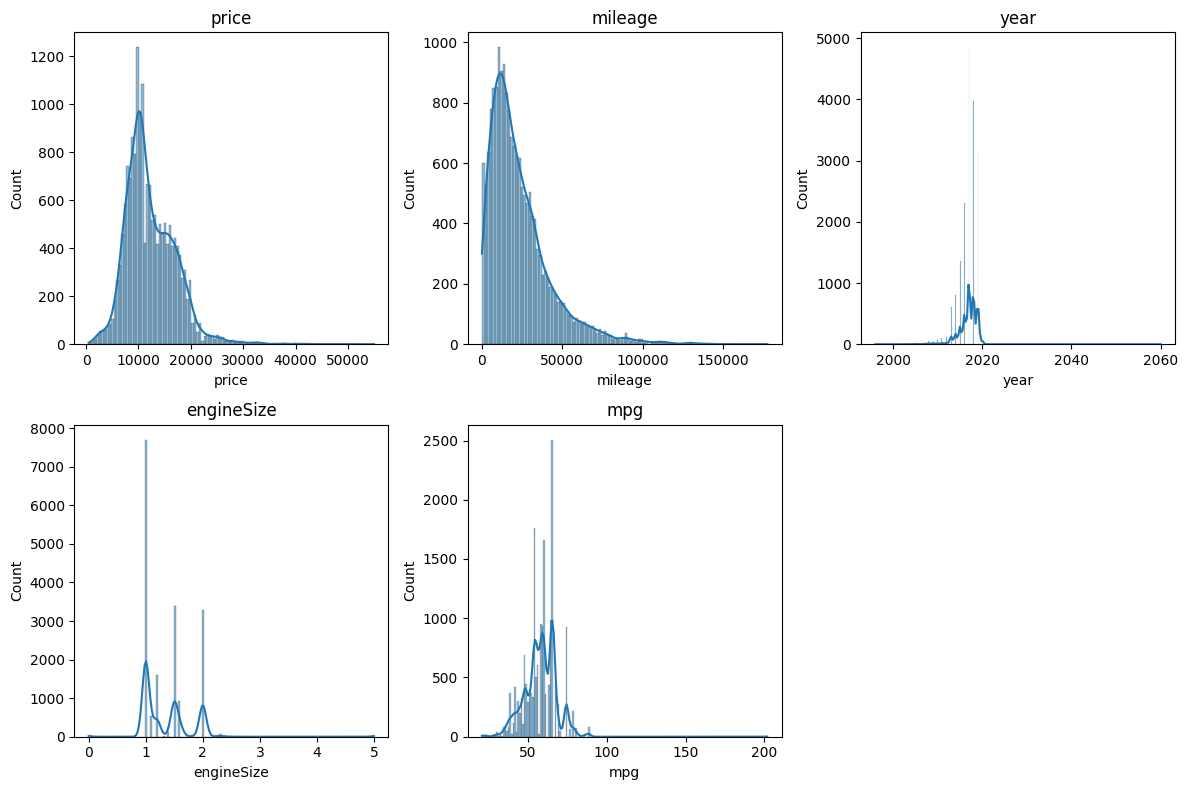

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
columns = ["price", "mileage", "year", "engineSize", "mpg"]
plt.figure(figsize=(12,8))
for i, col in enumerate(columns, 1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# Observations:
# Price distribution shows how car prices vary.
# Mileage indicates usage of vehicles.
# Year shows manufacturing year distribution.
# Engine Size distribution shows common engine capacities.
# MPG shows fuel efficiency distribution.

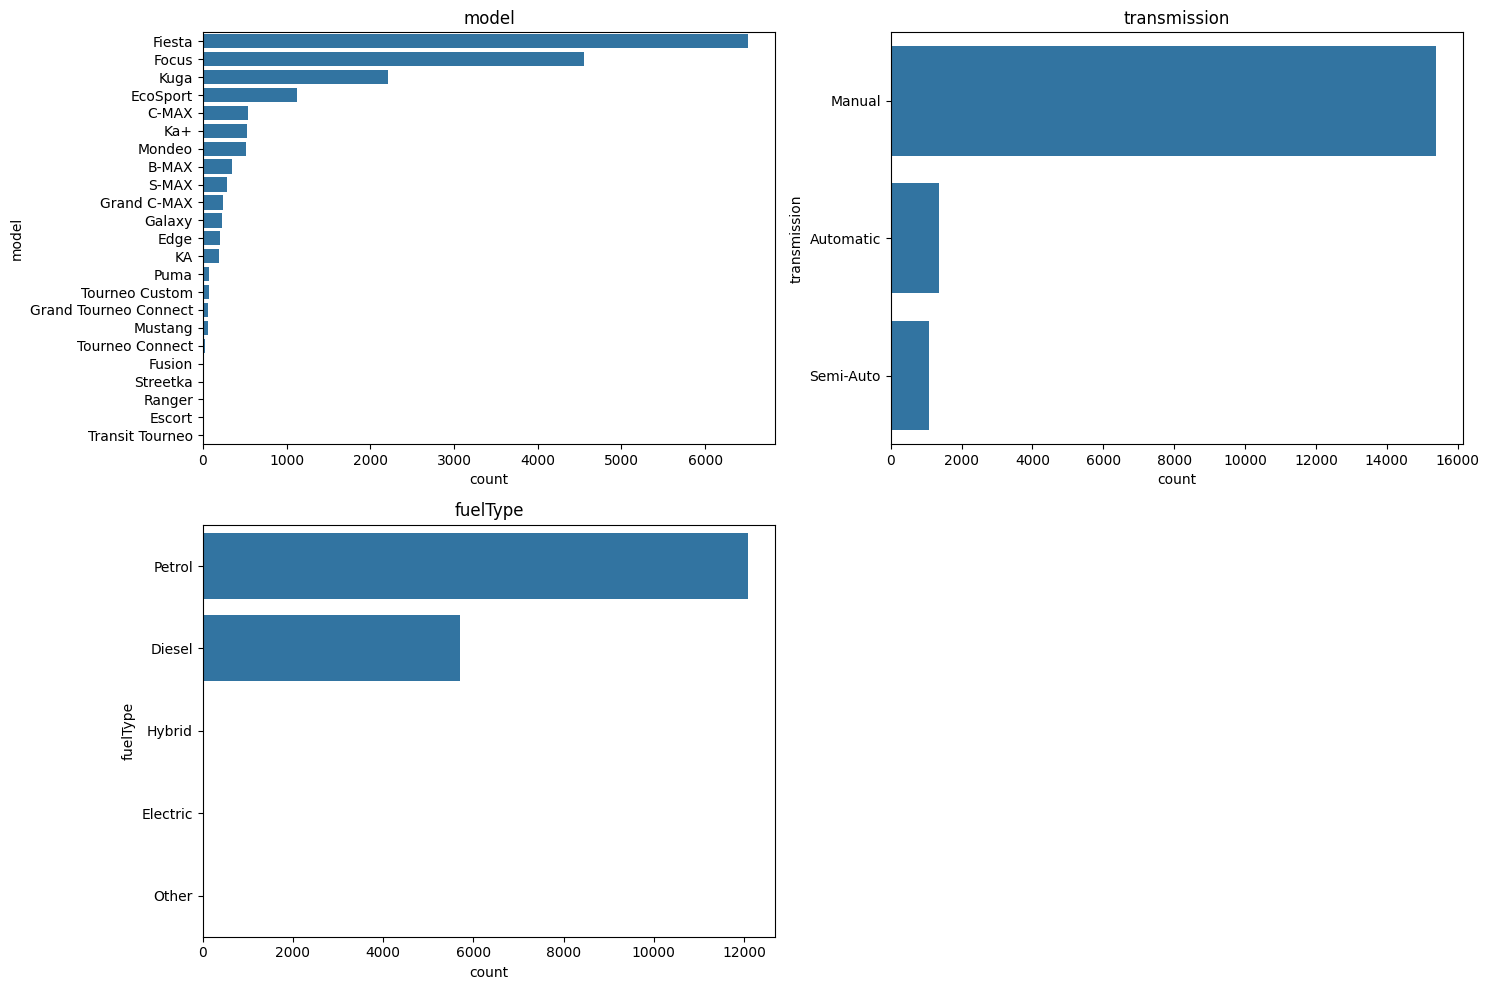

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
# Categorical Columns
cat_cols = ["model", "transmission", "fuelType"]
plt.figure(figsize=(15,10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2,2,i)
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(col)
plt.tight_layout()
plt.show()

# Observations:
# Most common car model can be identified.
# Most used transmission type can be observed.
# Most popular fuel type can be identified.
# These trends help understand the Ford car market.

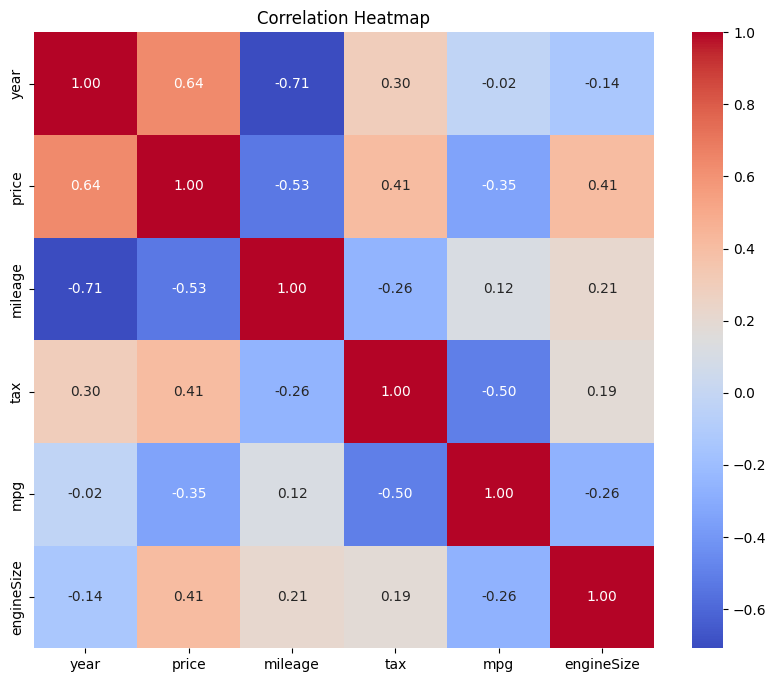

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
# Correlation Matrix
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
# Observations:
# Features with high positive correlation appear close to +1.
# Features with high negative correlation appear close to -1.
# Check which features have the strongest relationship with price.

In [10]:
print("Independent Features (X):")
X = df.drop("price", axis=1)
print(X.columns)
print("\nDependent Feature (Y):")
Y = df["price"]
print(Y.name)
# Reason:
# 'price' is the target variable to be predicted.
# Remaining columns are used as input features.

Independent Features (X):
Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

Dependent Feature (Y):
price


In [11]:
# Before Encoding
print("Before Encoding")
print(df[["transmission", "fuelType"]].head())
# One-Hot Encoding
df_encoded = pd.get_dummies(df)
# After Encoding
print("\nAfter Encoding")
print(df_encoded.head())
print("\nNew Shape:")
print(df_encoded.shape)
# Observations:
# Categorical columns are converted into binary (0/1) columns.
# Encoded dataset is now suitable for Machine Learning.

Before Encoding
  transmission fuelType
0    Automatic   Petrol
1       Manual   Petrol
2       Manual   Petrol
3       Manual   Petrol
4    Automatic   Petrol

After Encoding
   year  price  mileage  tax   mpg  engineSize  model_B-MAX  model_C-MAX  \
0  2017  12000    15944  150  57.7         1.0        False        False   
1  2018  14000     9083  150  57.7         1.0        False        False   
2  2017  13000    12456  150  57.7         1.0        False        False   
3  2019  17500    10460  145  40.3         1.5        False        False   
4  2019  16500     1482  145  48.7         1.0        False        False   

   model_EcoSport  model_Edge  ...  model_Tourneo Custom  \
0           False       False  ...                 False   
1           False       False  ...                 False   
2           False       False  ...                 False   
3           False       False  ...                 False   
4           False       False  ...                 False   

   mod

In [12]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler
# Independent Features
X = df.drop("price", axis=1)
# One-Hot Encoding
X = pd.get_dummies(X)
# Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Convert to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
# First 5 Rows
print("First 5 Rows of Scaled Data:")
print(X_scaled.head())

First 5 Rows of Scaled Data:
       year   mileage       tax       mpg  engineSize  model_B-MAX  \
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561    -0.141575   
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561    -0.141575   
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561    -0.141575   
3  1.041726 -0.665405  0.510777 -1.737858    0.345325    -0.141575   
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561    -0.141575   

   model_C-MAX  model_EcoSport  model_Edge  model_Escort  ...  \
0    -0.177155       -0.259896   -0.107903     -0.007493  ...   
1    -0.177155       -0.259896   -0.107903     -0.007493  ...   
2    -0.177155       -0.259896   -0.107903     -0.007493  ...   
3    -0.177155       -0.259896   -0.107903     -0.007493  ...   
4    -0.177155       -0.259896   -0.107903     -0.007493  ...   

   model_Tourneo Custom  model_Transit Tourneo  transmission_Automatic  \
0             -0.062361              -0.007493                3.486416   
1          

Dataset Loaded Successfully

Missing Values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Shape After Cleaning:
(17812, 9)


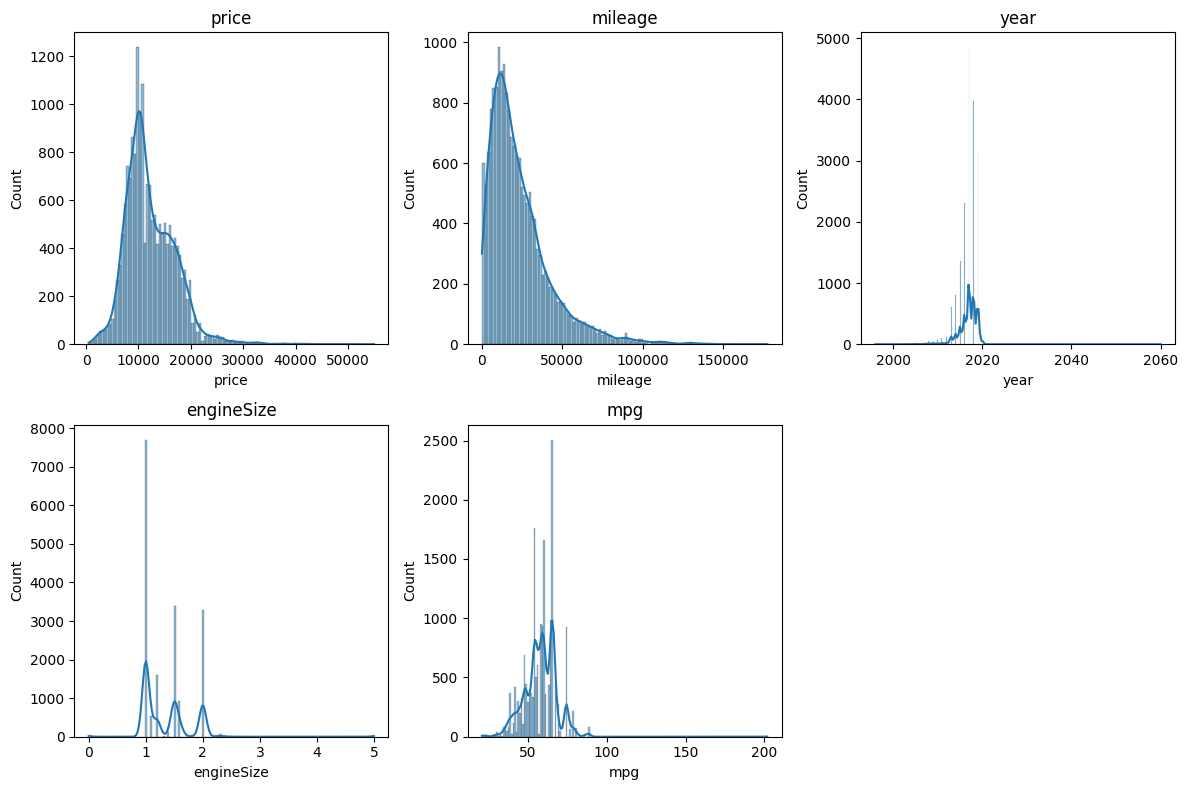

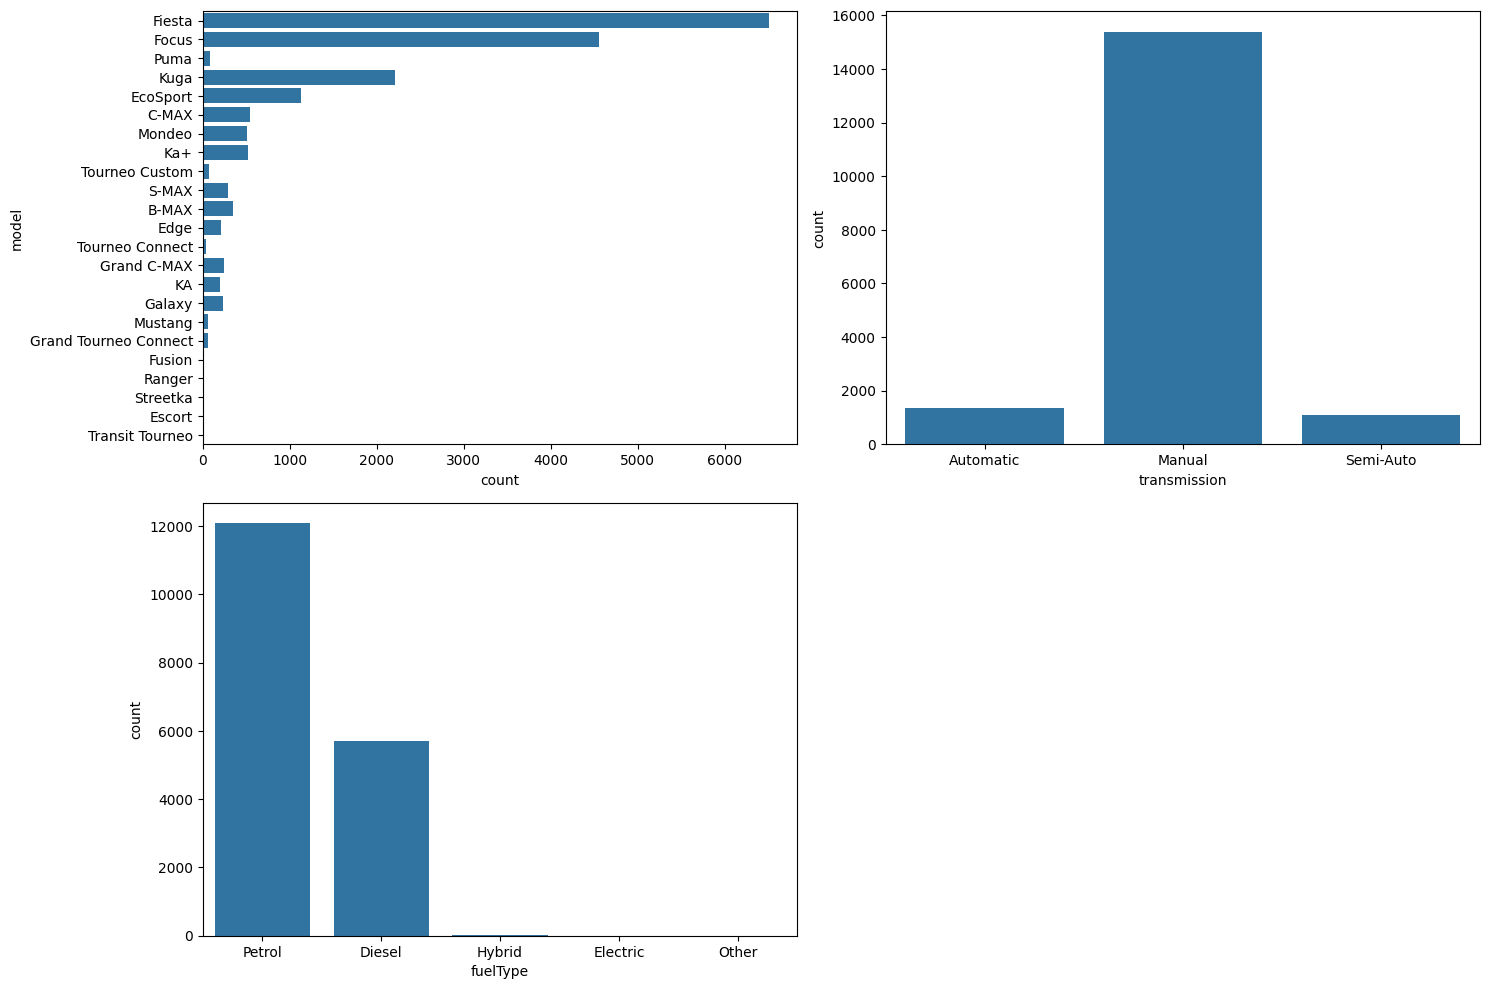

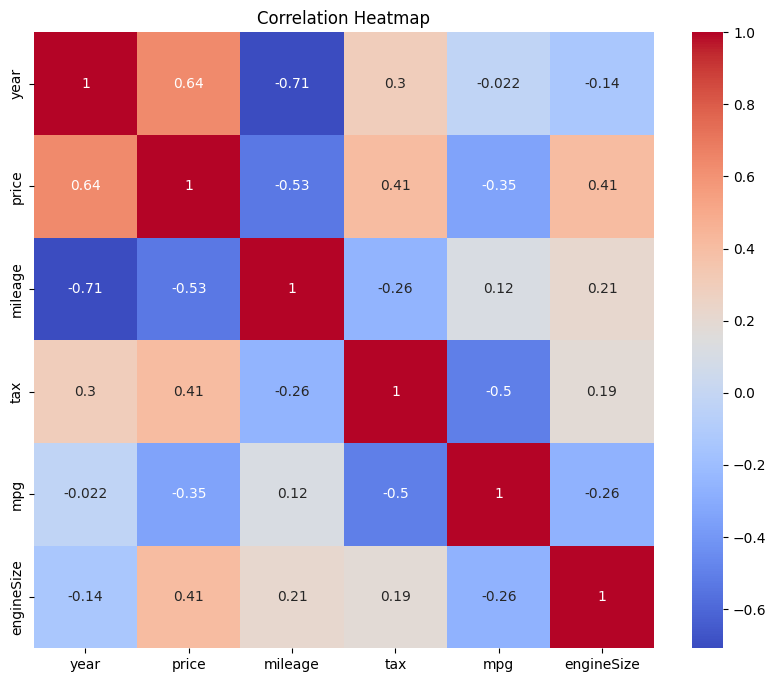


Input Features:
Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

Output Feature:
price

Shape After Encoding:
(17812, 36)

Scaled Data
       year   mileage       tax       mpg  engineSize  model_B-MAX  \
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561    -0.141575   
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561    -0.141575   
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561    -0.141575   
3  1.041726 -0.665405  0.510777 -1.737858    0.345325    -0.141575   
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561    -0.141575   

   model_C-MAX  model_EcoSport  model_Edge  model_Escort  ...  \
0    -0.177155       -0.259896   -0.107903     -0.007493  ...   
1    -0.177155       -0.259896   -0.107903     -0.007493  ...   
2    -0.177155       -0.259896   -0.107903     -0.007493  ...   
3    -0.177155       -0.259896   -0.107903     -0.007493  ...   
4    -0.177155       -0.259896   -0.107903   

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pandas as pd
filepath = "/content/drive/MyDrive/ford_car_dataset.csv"
df = pd.read_csv(filepath)
print("Dataset Loaded Successfully")
# Remove Missing Values
print("\nMissing Values:")
print(df.isnull().sum())
df = df.dropna()
# Remove Duplicates
df = df.drop_duplicates()
print("\nShape After Cleaning:")
print(df.shape)

# Histograms
numeric_cols = ["price","mileage","year","engineSize","mpg"]
plt.figure(figsize=(12,8))
for i,col in enumerate(numeric_cols,1):
    plt.subplot(2,3,i)
    sns.histplot(df[col],kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# Count Plots
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
sns.countplot(y="model",data=df)
plt.subplot(2,2,2)
sns.countplot(x="transmission",data=df)
plt.subplot(2,2,3)
sns.countplot(x="fuelType",data=df)
plt.tight_layout()
plt.show()

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

X = df.drop("price",axis=1)
Y = df["price"]
print("\nInput Features:")
print(X.columns)
print("\nOutput Feature:")
print(Y.name)

X = pd.get_dummies(X)

print("\nShape After Encoding:")
print(X.shape)

#Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled,
                        columns=X.columns)
print("\nScaled Data")
print(X_scaled.head())
print("\nPreprocessing Completed Successfully")